<a href="https://colab.research.google.com/github/RishiSujith/GANS/blob/main/dcgans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import os

In [ ]:
!pip install datasets
from datasets import load_dataset
from PIL import Image

os.makedirs("/content/data/faces", exist_ok=True)

ds = load_dataset("merkol/ffhq-256", split="train")

for i, item in enumerate(ds):
    item["image"].save(f"/content/data/faces/{i:05d}.jpg")
    if i % 1000 == 0:
        print(f"{i}/{len(ds)} saved...")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/450 [00:00<?, ?B/s]

data/train-00000-of-00015-991c06ed507bdb(…):   0%|          | 0.00/492M [00:00<?, ?B/s]

data/train-00001-of-00015-78537a18b94b88(…):   0%|          | 0.00/494M [00:00<?, ?B/s]

data/train-00002-of-00015-99699fe43dfbed(…):   0%|          | 0.00/495M [00:00<?, ?B/s]

...

data/train-00012-of-00015-a96411675f1cda(…):   0%|          | 0.00/493M [00:00<?, ?B/s]

data/train-00013-of-00015-467245f3e9cb28(…):   0%|          | 0.00/494M [00:00<?, ?B/s]

data/train-00014-of-00015-267e348c5192fc(…):   0%|          | 0.00/494M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/70000 [00:00<?, ? examples/s]

0/70000 saved...
1000/70000 saved...
2000/70000 saved...
3000/70000 saved...
4000/70000 saved...
5000/70000 saved...
6000/70000 saved...
7000/70000 saved...
8000/70000 saved...
9000/70000 saved...
10000/70000 saved...
11000/70000 saved...
12000/70000 saved...
13000/70000 saved...
14000/70000 saved...
15000/70000 saved...
16000/70000 saved...
17000/70000 saved...
18000/70000 saved...
19000/70000 saved...
20000/70000 saved...
21000/70000 saved...
22000/70000 saved...
23000/70000 saved...
24000/70000 saved...
25000/70000 saved...
26000/70000 saved...
27000/70000 saved...
28000/70000 saved...
29000/70000 saved...
30000/70000 saved...
31000/70000 saved...
32000/70000 saved...
33000/70000 saved...
34000/70000 saved...
35000/70000 saved...
36000/70000 saved...
37000/70000 saved...
38000/70000 saved...
39000/70000 saved...
40000/70000 saved...
41000/70000 saved...
42000/70000 saved...
43000/70000 saved...
44000/70000 saved...
45000/70000 saved...
46000/70000 saved...
47000/70000 saved...
48000

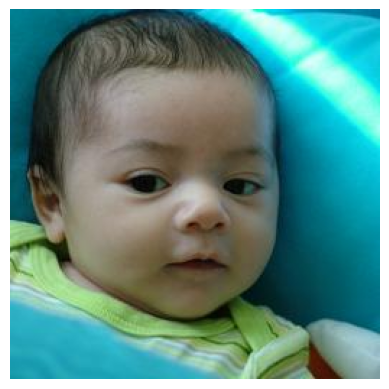

In [ ]:
img = Image.open("/content/data/faces/00000.jpg")
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:

DATAROOT   = "/content/data"   # Folder containing the dataset (ImageFolder expects subfolders inside)
BATCH_SIZE = 128               # How many images to process per training step
IMAGE_SIZE = 64                # Resize all images to 64×64 — DCGAN was designed around this size
NC         = 3                 # Number of image channels — 3 for RGB
NZ         = 100               # Length of the latent noise vector fed into the Generator
NGF        = 64                # Controls the width (number of feature maps) inside the Generator
NDF        = 64                # Controls the width (number of feature maps) inside the Discriminator
NUM_EPOCHS = 5                 # How many full passes through the dataset
LR         = 0.0002            # Learning rate — from the original DCGAN paper, works well as-is
BETA1      = 0.5               # Adam's momentum term — lower than default (0.9) for more stable GAN training
WORKERS    = 2

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Using: cuda


In [ ]:
transform=transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])


In [ ]:
dataset=torchvision.datasets.ImageFolder(
    root=DATAROOT,
    transform=transform,
)

dataloader=torch.utils.data.DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=WORKERS,
)

print(f"len of dataset {len(dataset):,} images, batches per epoch: {len(dataloader)}")

len of dataset 70,000 images, batches per epoch: 547


In [ ]:
#weight initialisation
#dcgans paper says wwights from 0-0.2 is better than pytorchs default
def weights_init(m):
  classname=m.__class__.__name__ #get the layer type as a string
  if classname.find("Conv") !=-1:
    nn.init.normal_(m.weight.data,0.0,0.02)
  elif classname.find("BatchNorm") !=-1:
    nn.init.normal_(m.weight.data,1.0,0.02)
    nn.init.constant_(m.bias.data,0)



In [ ]:
#GENERATOR
class Generator(nn.Module):
  def __init__(self):
    super().__init__()
    self.main=nn.Sequential(
        nn.ConvTranspose2d(NZ,NGF*8,4,1,0,bias=False),
        nn.BatchNorm2d(NGF*8),
        nn.ReLU(True),
        #block2
        nn.ConvTranspose2d(NGF*8,NGF*4,4,2,1,bias=False),
        nn.BatchNorm2d(NGF*4),
        nn.ReLU(True),
        #block3
        nn.ConvTranspose2d(NGF*4,NGF*2,4,2,1,bias=False),
        nn.BatchNorm2d(NGF*2),
        nn.ReLU(True),
        #block4
        nn.ConvTranspose2d(NGF * 2, NGF, 4, 2, 1, bias=False),
        nn.BatchNorm2d(NGF),
        nn.ReLU(True),
        #output block
        nn.ConvTranspose2d(NGF,NC,4,2,1,bias=False),
        nn.Tanh()
    )
  def forward(self,z):
    #inputshape: (batch_size,NZ,1,1)
    #output shape: (batch_size,NC,64,64)
    return self.main(z)









In [ ]:
class Discriminator(nn.Module):
  def __init__(self):
    super().__init__()
    self.main=nn.Sequential(
        #block1 (NC,64,64) => (NDF,32,32)
        #no batchnorm
        nn.Conv2d(NC,NDF,4,2,1,bias=False),
        nn.LeakyReLU(0.2,inplace=True),
        #block2 (NDF,32,32)->(NDF*2,16,16)
        nn.Conv2d(NDF,NDF*2,4,2,1,bias=False),
        nn.BatchNorm2d(NDF*2),
        nn.LeakyReLU(0.2,inplace=True),
        #block3
        nn.Conv2d(NDF*2,NDF*4,4,2,1,bias=False),
        nn.BatchNorm2d(NDF*4),
        nn.LeakyReLU(0.2,inplace=True),
        #block4
        nn.Conv2d(NDF * 4, NDF * 8, 4, 2, 1, bias=False),
        nn.BatchNorm2d(NDF * 8),
        nn.LeakyReLU(0.2, inplace=True),
        #output
        nn.Conv2d(NDF*8,1,4,1,0,bias=False),
        nn.Sigmoid()


    )
  def forward(self,x):
    return self.main(x).view(-1)

In [ ]:
#BUILD MODEL
netG=Generator().to(device)
netD=Discriminator().to(device)
netG.apply(weights_init)
netD.apply(weights_init)
print("models ready")

models ready


In [ ]:
from torch.optim import optimizer
#Loss and optim
criterion=nn.BCELoss()

optimizerD=optim.Adam(netD.parameters(),lr=LR,betas=(BETA1,0.999))
optimizerG=optim.Adam(netG.parameters(),lr=LR,betas=(BETA1,0.999))

#noise
fixed_noise=torch.randn(64,NZ,1,1,device=device)
G_losses=[]
D_losses=[]
img_list=[]


starting training loop
[1/5][0/547] Loss_D: 1.3734  Loss_G: 5.0239
[1/5][50/547] Loss_D: 2.8131  Loss_G: 24.6011
[1/5][100/547] Loss_D: 0.9989  Loss_G: 10.9284
[1/5][150/547] Loss_D: 0.9862  Loss_G: 4.3691
[1/5][200/547] Loss_D: 0.1943  Loss_G: 4.3848
[1/5][250/547] Loss_D: 1.9501  Loss_G: 3.4334
[1/5][300/547] Loss_D: 0.6165  Loss_G: 3.7714
[1/5][350/547] Loss_D: 0.5091  Loss_G: 4.3562
[1/5][400/547] Loss_D: 0.8902  Loss_G: 6.5919
[1/5][450/547] Loss_D: 0.7638  Loss_G: 5.1201
[1/5][500/547] Loss_D: 0.5461  Loss_G: 2.9902
[2/5][0/547] Loss_D: 0.3881  Loss_G: 4.5606
[2/5][50/547] Loss_D: 0.9705  Loss_G: 4.1659
[2/5][100/547] Loss_D: 0.3704  Loss_G: 4.4554
[2/5][150/547] Loss_D: 1.3227  Loss_G: 14.0933
[2/5][200/547] Loss_D: 0.5130  Loss_G: 7.1236
[2/5][250/547] Loss_D: 0.3087  Loss_G: 5.7186
[2/5][300/547] Loss_D: 0.3529  Loss_G: 4.8853
[2/5][350/547] Loss_D: 0.3673  Loss_G: 4.7858
[2/5][400/547] Loss_D: 0.4590  Loss_G: 5.3112
[2/5][450/547] Loss_D: 0.4110  Loss_G: 3.3709
[2/5][500/547]

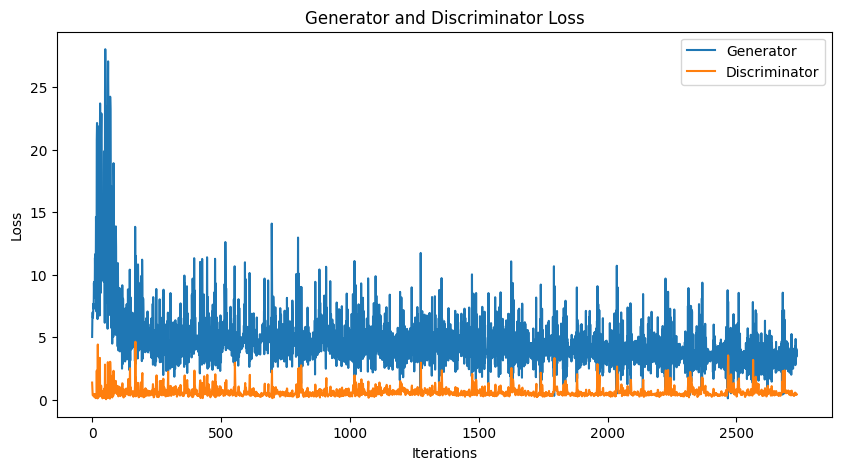

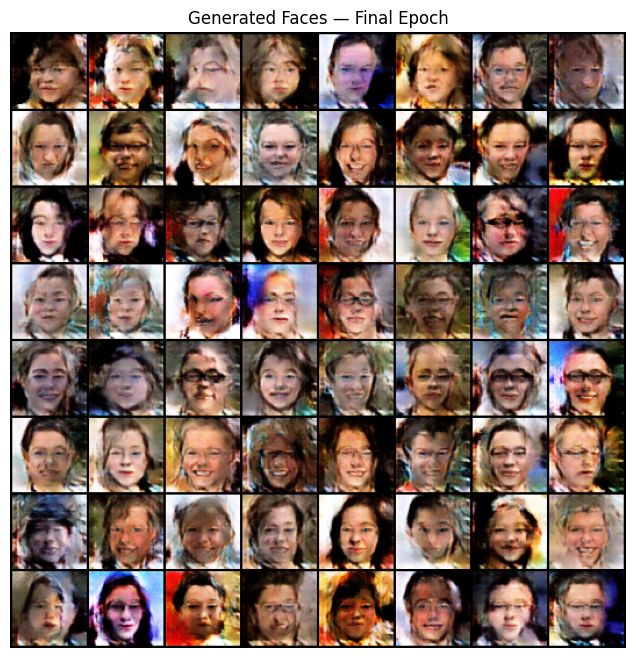

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#training loop
print("starting training loop")
for epoch in range(NUM_EPOCHS):
  for i,(real_images,_) in enumerate(dataloader):
    #train disc
    netD.zero_grad() #reset gradient from previous iteration
    real_images=real_images.to(device)
    b_size = real_images.size(0)
    batch_size=real_images.size(0)
    labels=torch.full((b_size,),1.0,device=device)

    output=netD(real_images)
    errD_real=criterion(output,labels)
    errD_real.backward()
    noise=torch.randn(b_size,NZ,1,1,device=device) #sample noise latent vector
    fake=netG(noise)
    labels.fill_(0.0) #label the fake data
    # .detach() cuts the fake tensor from G's computation graph
    # Without it, .backward() would try to compute gradients all the way back through G

    output=netD(fake.detach())
    errD_fake=criterion(output,labels)
    errD_fake.backward()
    optimizerD.step()

    errD=errD_real+errD_fake

    #Train generator

    netG.zero_grad()

    labels.fill_(1.0)
    output=netD(fake)
    errG=criterion(output,labels)
    errG.backward()
    optimizerG.step()

    #logging
    G_losses.append(errG.item())
    D_losses.append(errD.item())

    if i % 50 == 0:
            print(
                f"[{epoch+1}/{NUM_EPOCHS}][{i}/{len(dataloader)}] "
                f"Loss_D: {errD.item():.4f}  Loss_G: {errG.item():.4f}"
            )


    with torch.no_grad():
        fake_snapshot = netG(fixed_noise).detach().cpu()


    img_list.append(vutils.make_grid(fake_snapshot, normalize=True))

print("\nTraining done!")

torch.save(netG.state_dict(), "/content/generator.pth")
torch.save(netD.state_dict(), "/content/discriminator.pth")

#Plot Loss Curves

plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss")
plt.plot(G_losses, label="Generator")
plt.plot(D_losses, label="Discriminator")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

#Display Generated Images

# img_list[-1] is the grid from the final epoch
# .permute(1, 2, 0) reorders dimensions from PyTorch's (C, H, W) to matplotlib's (H, W, C)
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Generated Faces — Final Epoch")
plt.imshow(img_list[-1].permute(1, 2, 0))
plt.show()

#Download Results

from google.colab import files
files.download("/content/generator.pth")
files.download("/content/discriminator.pth")




